# Visualisation de la cascade wavelet

Ce notebook est adapté aux sorties de `wave_cascade_generator.py`.

Objectif de la cascade :

```text
cA2
-> diffusion j2 -> [cH2, cV2, cD2]
-> IDWT -> cA1
-> diffusion j1 -> [cH1, cV1, cD1]
-> IDWT -> image finale
```

Le notebook :

1. recharge les coefficients réels `j2`, `j1` ;
2. recharge les sorties de la cascade générée ;
3. compare les coefficients à chaque niveau ;
4. compare les approximations reconstruites intermédiaires (`cA1`) ;
5. compare les **images finales** ;
6. calcule le **PhyFID aux étapes image** de la cascade : coarse `cA2`, après `w2 -> cA1`, puis après `w1 -> image finale`.


---
## Imports et utilitaires

In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.functional import adaptive_avg_pool2d
from torch.utils.data import DataLoader, TensorDataset
import pywt


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "wave_diffusion.py").exists() and (candidate / "lib").exists():
            return candidate
    raise RuntimeError("Impossible de trouver la racine du projet RT-Diffusion.")

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from pytorch_fid.fid_score import calculate_frechet_distance as pytorch_fid_distance
from pytorch_fid.inception import InceptionV3

from lib.PhyFID.metrics import compare_datasets
from lib.PhyFID.utils import evaluate_phyfid_dataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PROJECT_ROOT =", project_root)
print("DEVICE =", DEVICE)


PROJECT_ROOT = /home/chapuissamuel/Documents/code/RT-Diffusion
DEVICE = cpu


In [2]:
import matplotlib.pyplot as plt

REPORT_PLOT_STYLE = {
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
}
plt.rcParams.update(REPORT_PLOT_STYLE)


In [3]:
def load_pt_dataset(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    return torch.load(path, map_location="cpu", weights_only=True)


def ensure_tensor(x):
    return x if torch.is_tensor(x) else torch.as_tensor(x)


def squeeze_channel(images):
    images = ensure_tensor(images)
    if images.ndim == 4 and images.shape[1] == 1:
        return images[:, 0]
    return images


def print_dataset_summary(name, images):
    tensor = ensure_tensor(images).float()
    print(
        f"{name:<28} shape={tuple(tensor.shape)!s:<18} dtype={tensor.dtype} "
        f"min={tensor.min().item():8.3f} max={tensor.max().item():8.3f} "
        f"mean={tensor.mean().item():8.3f} std={tensor.std().item():8.3f}"
    )


def show_grid(images, n=16, cols=4, cmap="gray", seed=0, title=None, colorbar=False):
    images = ensure_tensor(images)
    if images.ndim == 4 and images.shape[1] == 1:
        images = images[:, 0]

    rng = np.random.default_rng(seed)
    total = images.shape[0]
    n = min(n, total)
    rows = int(np.ceil(n / cols))
    indices = rng.choice(total, size=n, replace=False)

    if colorbar:
        fig = plt.figure(figsize=(cols * 2.2 + 0.45, rows * 2.2), constrained_layout=True)
        gs = fig.add_gridspec(rows, cols + 1, width_ratios=[1] * cols + [0.06], wspace=0.02)
        axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(cols)] for r in range(rows)])
        cax = fig.add_subplot(gs[:, -1])
    else:
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2), squeeze=False, constrained_layout=True)
        cax = None

    im_ref = None
    for i, idx in enumerate(indices):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        img = images[idx].detach().cpu().numpy()
        im_ref = ax.imshow(img, cmap=cmap)
        ax.set_title(f"idx={idx}")
        ax.axis("off")

    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=16)
    if colorbar and im_ref is not None:
        fig.colorbar(im_ref, cax=cax)
    plt.show()


def reconstruct_wavelet_sample(coeffs, wavelet="db1", mode="periodization"):
    coeffs = ensure_tensor(coeffs).detach().cpu().numpy()
    cA = coeffs[0]
    cH = coeffs[1]
    cV = coeffs[2]
    cD = coeffs[3]
    return pywt.idwt2((cA, (cH, cV, cD)), wavelet=wavelet, mode=mode)


def reconstruct_all_wavelet_samples(coeffs_array, wavelet="db1", mode="periodization"):
    coeffs_array = ensure_tensor(coeffs_array)
    return np.stack([
        reconstruct_wavelet_sample(coeffs, wavelet=wavelet, mode=mode)
        for coeffs in coeffs_array
    ], axis=0)


def upsample_approximation_to_image(approximation, current_level, wavelet="db1", mode="periodization"):
    """
    Propage une approximation cA_j jusqu'a l'espace image 64x64 via des IDWT
    successives avec details nuls aux niveaux plus fins.

    Cela permet d'evaluer un niveau j dans le meme espace que l'encodeur PhyFID
    final (1x64x64), sans entrainer un nouvel encodeur specifique aux coefficients.
    """
    approximation = ensure_tensor(approximation).detach().cpu().numpy().astype(np.float32)
    images = approximation
    for level in range(current_level, 0, -1):
        zeros = np.zeros_like(images, dtype=np.float32)
        images = np.stack([
            pywt.idwt2((img, (zero, zero, zero)), wavelet=wavelet, mode=mode)
            for img, zero in zip(images, zeros)
        ], axis=0)
    return images.astype(np.float32)


def reconstruct_level_projection(coeffs_array, level, wavelet="db1", mode="periodization"):
    """
    Reconstruit un echantillon de coefficients j en image 64x64 partielle.

    - j1 : reconstruction directe vers l'image finale.
    - j2 : reconstruction vers cA1 puis propagation en 64x64 avec details j1 nuls.
    - j3 : reconstruction vers cA2, puis cA1, puis 64x64 avec details plus fins nuls.

    Attention : ce n'est pas un PhyFID sur les coefficients bruts, mais un PhyFID
    sur leur projection dans l'espace image. C'est adapte pour localiser a quelle
    echelle la cascade commence a se degrader avec l'encodeur final disponible.
    """
    coeffs_array = ensure_tensor(coeffs_array)
    approx = reconstruct_all_wavelet_samples(coeffs_array, wavelet=wavelet, mode=mode)
    if level == 1:
        return approx.astype(np.float32)
    return upsample_approximation_to_image(
        approx,
        current_level=level - 1,
        wavelet=wavelet,
        mode=mode,
    )


def build_level_metric_inputs(real_coeffs, generated_coeffs, level, *, wavelet="db1", mode="periodization"):
    real_images = reconstruct_level_projection(real_coeffs[level], level, wavelet=wavelet, mode=mode)
    generated_images = reconstruct_level_projection(generated_coeffs[level], level, wavelet=wavelet, mode=mode)

    n_images = min(1000, len(real_images) // 2, len(generated_images))
    if n_images == 0:
        raise ValueError(f"Pas assez d'echantillons pour calculer les metriques au niveau j{level}.")

    reference = real_images[:n_images]
    datasets = {
        "val vs val": real_images[n_images:2 * n_images],
        f"val vs generated j{level}": generated_images[:n_images],
    }
    return reference, datasets, n_images


def to_numpy_images(images):
    images = squeeze_channel(images)
    return ensure_tensor(images).detach().cpu().numpy().astype(np.float32)


def prepare_images_for_fid(images):
    """Convertit NHW/NCHW/NHWC en RGB NCHW dans [0, 1]."""
    original_dtype = torch.as_tensor(images).dtype
    images = torch.as_tensor(images).detach().cpu().float()

    if images.ndim == 3:
        images = images.unsqueeze(1)
    elif images.ndim == 4 and images.shape[-1] in (1, 3) and images.shape[1] not in (1, 3):
        images = images.permute(0, 3, 1, 2)
    if images.ndim != 4:
        raise ValueError(f"Format non supporte: {tuple(images.shape)}")

    if original_dtype == torch.uint8 or images.max() > 2:
        images = images / 255.0
    elif images.min() < 0 and images.max() <= 1:
        images = (images + 1.0) / 2.0

    images = images.clamp(0.0, 1.0)
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    if images.shape[1] != 3:
        raise ValueError(f"FID attend 1 ou 3 canaux, recu: {images.shape[1]}")
    return images


def extract_fid_features(images, model, batch_size, device):
    images = prepare_images_for_fid(images)
    loader = DataLoader(TensorDataset(images), batch_size=batch_size, shuffle=False)
    features = []

    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            prediction = model(batch.to(device))[0]
            if prediction.shape[-2:] != (1, 1):
                prediction = adaptive_avg_pool2d(prediction, output_size=(1, 1))
            features.append(prediction.flatten(1).cpu().numpy())

    return np.concatenate(features, axis=0)


def fid_from_features(reference_features, compared_features):
    reference_mu = np.mean(reference_features, axis=0)
    reference_sigma = np.cov(reference_features, rowvar=False)
    compared_mu = np.mean(compared_features, axis=0)
    compared_sigma = np.cov(compared_features, rowvar=False)
    return max(0.0, float(pytorch_fid_distance(reference_mu, reference_sigma, compared_mu, compared_sigma)))


def compute_inception_fid_scores(reference_images, datasets, n_images, dims=64, batch_size=25, device=DEVICE):
    fid_block = InceptionV3.BLOCK_INDEX_BY_DIM[dims]
    fid_model = InceptionV3([fid_block]).to(device)

    reference_features = extract_fid_features(reference_images[:n_images], fid_model, batch_size, device)
    scores = {}
    for name, dataset in datasets.items():
        compared_features = extract_fid_features(dataset[:n_images], fid_model, batch_size, device)
        scores[name] = fid_from_features(reference_features, compared_features)

    del fid_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return scores


def wavelet_coeffs_to_single_channel_images(coeffs, wavelet="db1", mode="periodization"):
    coeffs = ensure_tensor(coeffs)
    if coeffs.ndim == 4 and coeffs.shape[1] >= 4:
        return reconstruct_all_wavelet_samples(coeffs[:, :4], wavelet=wavelet, mode=mode)
    return to_numpy_images(coeffs)


---
## Configuration

In [4]:
CASCADE_LEVELS = [2, 1]
COARSE_LEVEL = max(CASCADE_LEVELS)
COARSE_KEY = COARSE_LEVEL + 1
DATASET = "validation"  # training / validation / test

DATA_ROOT = project_root / "data" / "RT64" / "processed"
OUTPUT_DIR = project_root / "outputs" / "generated" / "cascade_sgm_hcirc_blurpool_eps00001"
CSV_DIR = project_root / "outputs" / "logs" / "cascade_sgm_hcirc_blurpool_eps00001"
WAVELET = "db1"
BORDER_MODE = "periodization"
N_SAMPLES = 8
SEED = 0

REAL_COEFF_PATHS = {
    level: DATA_ROOT / f"j{level}_{DATASET}.pt"
    for level in CASCADE_LEVELS
}

LOSS_PATHS = {
    COARSE_KEY: CSV_DIR / f"coarse_cA{COARSE_LEVEL}_RT64.csv",
    **{level: CSV_DIR / f"wave_j{level}_RT64.csv" for level in CASCADE_LEVELS},
}

GENERATED_COEFF_PATHS = {
    COARSE_KEY: OUTPUT_DIR / f"j{COARSE_LEVEL}_initial_cA.pt",
    **{level: OUTPUT_DIR / f"j{level}_generated_coefficients.pt" for level in CASCADE_LEVELS},
}

RECONSTRUCTED_CA_PATHS = {
    level - 1: OUTPUT_DIR / f"j{level - 1}_reconstructed_cA.pt"
    for level in CASCADE_LEVELS
    if level > 1
}

FINAL_GENERATED_IMAGES_PT = OUTPUT_DIR / "generated_images.pt"

PHYFID_ENCODER = project_root / "outputs" / "phyFID" / "64phyfid_encoder.pt"
PHYFID_BATCH_SIZE = 128

FID_DIMS = 64
FID_BATCH_SIZE = 25
FID_DEVICE = DEVICE


CMAP = "gray"  # "gray" / "jet" / "viridis" / "plasma" / "inferno" / "magma" / "cividis"


---
## Chargement des données de la cascade

In [5]:
real_coeffs = {level: load_pt_dataset(path) for level, path in REAL_COEFF_PATHS.items()}
generated_coeffs = {level: load_pt_dataset(path) for level, path in GENERATED_COEFF_PATHS.items()}
reconstructed_ca = {level: load_pt_dataset(path) for level, path in RECONSTRUCTED_CA_PATHS.items()}
final_generated_images = load_pt_dataset(FINAL_GENERATED_IMAGES_PT)

final_real_images = reconstruct_all_wavelet_samples(
    real_coeffs[1],
    wavelet=WAVELET,
    mode=BORDER_MODE,
)

for level in CASCADE_LEVELS:
    print_dataset_summary(f"real coeffs j{level}", real_coeffs[level])
    print_dataset_summary(f"generated coeffs j{level}", generated_coeffs[level])

print_dataset_summary(f"initial cA{COARSE_LEVEL}", generated_coeffs[COARSE_KEY])
for level in sorted(reconstructed_ca, reverse=True):
    print_dataset_summary(f"reconstructed cA{level}", reconstructed_ca[level])
print_dataset_summary("final real images", final_real_images)
print_dataset_summary("final generated images", final_generated_images)


real coeffs j2               shape=(4500, 4, 16, 16)  dtype=torch.float32 min=  -1.754 max=   4.000 mean=   0.512 std=   1.283
generated coeffs j2          shape=(2048, 4, 16, 16)  dtype=torch.float32 min=  -1.892 max=   3.824 mean=   0.506 std=   1.222
real coeffs j1               shape=(4500, 4, 32, 32)  dtype=torch.float32 min=  -0.793 max=   2.000 mean=   0.252 std=   0.645
generated coeffs j1          shape=(2048, 4, 32, 32)  dtype=torch.float32 min=  -0.858 max=   2.471 mean=   0.251 std=   0.616
initial cA2                  shape=(2048, 1, 16, 16)  dtype=torch.float32 min=   0.155 max=   3.824 mean=   1.973 std=   1.714
reconstructed cA1            shape=(2048, 1, 32, 32)  dtype=torch.float32 min=  -0.429 max=   2.471 mean=   0.986 std=   0.881
final real images            shape=(4500, 64, 64)     dtype=torch.float32 min=  -0.000 max=   1.000 mean=   0.497 std=   0.483
final generated images       shape=(2048, 1, 64, 64)  dtype=torch.float32 min=  -0.258 max=   1.262 mean=   0.4

In [6]:
# PhyFID aux etapes image de la cascade, avec reference reelle
PHYFID_ROOT = project_root / "outputs" / "phyFID"
PHYFID_ENCODER_64 = PHYFID_ROOT / "64phyfid_encoder.pt"
PHYFID_ENCODER_COARSE = PHYFID_ROOT / f"coarse_cA{COARSE_LEVEL}_phyfid_encoder.pt"
PHYFID_BATCH_SIZE = 128
PHYFID_MAX_IMAGES = 1000


def as_phyfid_batch(images):
    images = ensure_tensor(images).detach().cpu().float()
    if images.ndim == 3:
        images = images.unsqueeze(1)
    if images.ndim != 4 or images.shape[1] != 1:
        raise ValueError(f"PhyFID attend un batch scalaire NCHW ou NHW, recu {tuple(images.shape)}")
    return images


def compare_phyfid_stage(stage_name, reference_images, generated_images, encoder_path, *, max_images=PHYFID_MAX_IMAGES):
    encoder_path = Path(encoder_path)
    if not encoder_path.exists():
        raise FileNotFoundError(f"Encodeur PhyFID introuvable pour {stage_name}: {encoder_path}")

    reference_images = as_phyfid_batch(reference_images)
    generated_images = as_phyfid_batch(generated_images)
    n_images = min(max_images, len(reference_images) // 2, len(generated_images))
    if n_images == 0:
        raise ValueError(f"Pas assez d'images pour le PhyFID {stage_name}.")

    reference = reference_images[:n_images]
    reference_holdout = reference_images[n_images:2 * n_images]
    generated = generated_images[:n_images]

    return {
        "stage": stage_name,
        "n": n_images,
        "encoder": encoder_path.name,
        "ref_vs_ref": compare_datasets(reference, reference_holdout, encoder_path, batch_size=PHYFID_BATCH_SIZE, device=DEVICE),
        "ref_vs_generated": compare_datasets(reference, generated, encoder_path, batch_size=PHYFID_BATCH_SIZE, device=DEVICE),
    }


# coarse: cA2 natif, evalue avec l'encodeur PhyFID entraine sur cA2.
coarse_reference = real_coeffs[COARSE_LEVEL][:, 0:1]
coarse_generated = generated_coeffs[COARSE_KEY]

# w2: image intermediaire cA1. Comme il n'y a pas d'encodeur cA1 sauvegarde,
# on projette cA1 en 64x64 avec details plus fins nuls et on utilise l'encodeur 64.
w2_reference = upsample_approximation_to_image(
    squeeze_channel(real_coeffs[1][:, 0:1]),
    current_level=1,
    wavelet=WAVELET,
    mode=BORDER_MODE,
)
w2_generated = upsample_approximation_to_image(
    squeeze_channel(reconstructed_ca[1]),
    current_level=1,
    wavelet=WAVELET,
    mode=BORDER_MODE,
)

# w1: image finale native 64x64.
w1_reference = final_real_images
w1_generated = final_generated_images

phyfid_image_stage_scores = [
    compare_phyfid_stage(f"coarse cA{COARSE_LEVEL}", coarse_reference, coarse_generated, PHYFID_ENCODER_COARSE),
    compare_phyfid_stage("w2 -> cA1 projete 64", w2_reference, w2_generated, PHYFID_ENCODER_64),
    compare_phyfid_stage("w1 -> image finale", w1_reference, w1_generated, PHYFID_ENCODER_64),
]


def print_phyfid_stage_result(stage_name):
    matches = [row for row in phyfid_image_stage_scores if row["stage"] == stage_name]
    if not matches:
        raise KeyError(f"Score PhyFID introuvable pour {stage_name!r}")
    row = matches[0]
    print(
        f"PhyFID {row['stage']} | n={row['n']} | encoder={row['encoder']} | "
        f"ref vs ref={row['ref_vs_ref']:.4f} | ref vs generated={row['ref_vs_generated']:.4f}"
    )

print(f"{'Etape image':<28} {'n':>6} {'encodeur':<30} {'ref vs ref':>14} {'ref vs generated':>18}")
for row in phyfid_image_stage_scores:
    print(
        f"{row['stage']:<28} {row['n']:>6} {row['encoder']:<30} "
        f"{row['ref_vs_ref']:>14.4f} {row['ref_vs_generated']:>18.4f}"
    )


Etape image                       n encodeur                           ref vs ref   ref vs generated
coarse cA2                     1000 coarse_cA2_phyfid_encoder.pt           0.0000             0.0001
w2 -> cA1 projete 64           1000 64phyfid_encoder.pt                    0.5001             2.8304
w1 -> image finale             1000 64phyfid_encoder.pt                    0.6658             3.0953


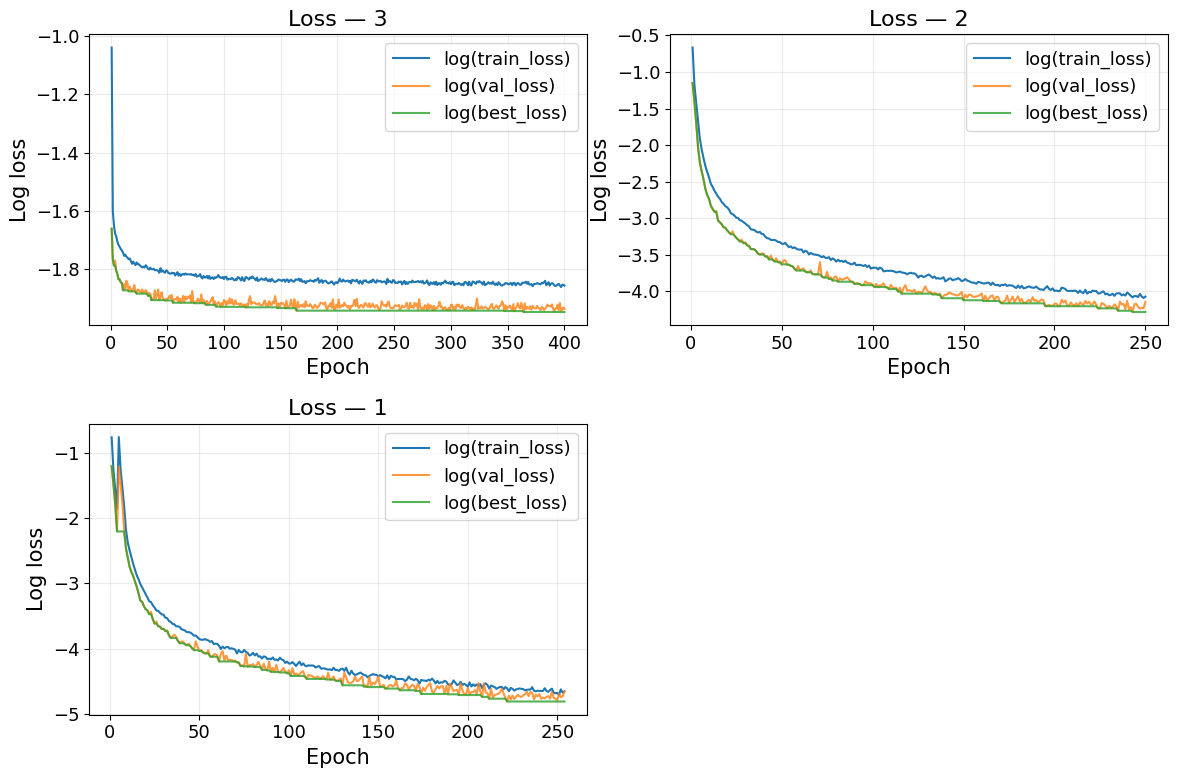

In [7]:
def plot_loss_curves(csv_paths, save=False, save_path="loss_curves.png"):
    """
    Affiche une courbe de loss par fichier CSV.

    Parameters
    ----------
    csv_paths : dict
        Dictionnaire de la forme {nom_ou_niveau: chemin_csv}.
    """

    n_curves = len(csv_paths)
    n_cols = 2
    n_rows = int(np.ceil(n_curves / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, 4 * n_rows),
        squeeze=False,
    )

    axes = axes.ravel()
    eps = 1e-12

    for index, (name, path) in enumerate(csv_paths.items()):
        path = Path(path)

        if not path.exists():
            raise FileNotFoundError(f"Fichier de loss introuvable : {path}")

        data = np.genfromtxt(
            path,
            delimiter=",",
            names=True,
            dtype=None,
            encoding="utf-8",
        )

        if data.dtype.names is None:
            raise ValueError(
                f"Impossible de lire les colonnes du fichier {path}."
            )

        required_columns = {"epoch", "train_loss"}
        missing_columns = required_columns.difference(data.dtype.names)

        if missing_columns:
            raise ValueError(
                f"Colonnes manquantes dans {path}: {sorted(missing_columns)}. "
                f"Colonnes disponibles: {data.dtype.names}"
            )

        epochs = np.atleast_1d(data["epoch"])
        train_loss = np.atleast_1d(data["train_loss"])

        val_loss = (
            np.atleast_1d(data["val_loss"])
            if "val_loss" in data.dtype.names
            else None
        )

        best_loss = (
            np.atleast_1d(data["best_loss"])
            if "best_loss" in data.dtype.names
            else None
        )

        axis = axes[index]

        axis.plot(
            epochs,
            np.log(np.clip(train_loss, eps, None)),
            label="log(train_loss)",
        )

        if val_loss is not None:
            axis.plot(
                epochs,
                np.log(np.clip(val_loss, eps, None)),
                label="log(val_loss)",
                alpha=0.8,
            )

        if best_loss is not None:
            axis.plot(
                epochs,
                np.log(np.clip(best_loss, eps, None)),
                label="log(best_loss)",
                alpha=0.8,
            )

        axis.set_xlabel("Epoch")
        axis.set_ylabel("Log loss")
        axis.set_title(f"Loss — {name}")
        axis.grid(alpha=0.25)
        axis.legend()

    # Désactive les sous-figures inutilisées
    for index in range(n_curves, len(axes)):
        axes[index].axis("off")

    fig.tight_layout()

    if save:
        fig.savefig(save_path, bbox_inches="tight", dpi=200)

    plt.show()


plot_loss_curves(LOSS_PATHS, save=True, save_path=OUTPUT_DIR / "loss_curves.png")

---
## Fonctions de visualisation

In [8]:
def plot_wavelet_level_comparison(real_data,
                                  generated_data,
                                  level,
                                  n_examples=3,
                                  seed=0,
                                  channel_titles=None,
                                  cmap="gray"):
    real_data = ensure_tensor(real_data)
    generated_data = ensure_tensor(generated_data)

    n_examples = min(n_examples, len(real_data), len(generated_data))
    rng = np.random.default_rng(seed)
    indices = rng.choice(min(len(real_data), len(generated_data)), size=n_examples, replace=False)

    if channel_titles is None:
        channel_titles = ["Approximation cA", "Horizontal cH", "Vertical cV", "Diagonal cD"]

    fig, axes = plt.subplots(4, 2 * n_examples, figsize=(4 * n_examples, 8))

    for example, idx in enumerate(indices):
        real_coeff = real_data[idx]
        gen_coeff = generated_data[idx]
        c0 = example * 2

        axes[0, c0].imshow(real_coeff[0], cmap=cmap)
        axes[0, c0].set_title(f"Ref j{level}\n{channel_titles[0]}")
        axes[0, c0 + 1].imshow(gen_coeff[0], cmap=cmap)
        axes[0, c0 + 1].set_title(f"Gen j{level}\n{channel_titles[0]}")

        axes[1, c0].imshow(real_coeff[1], cmap=cmap)
        axes[1, c0].set_title(channel_titles[1])
        axes[1, c0 + 1].imshow(gen_coeff[1], cmap=cmap)
        axes[1, c0 + 1].set_title(channel_titles[1])

        axes[2, c0].imshow(real_coeff[2], cmap=cmap)
        axes[2, c0].set_title(channel_titles[2])
        axes[2, c0 + 1].imshow(gen_coeff[2], cmap=cmap)
        axes[2, c0 + 1].set_title(channel_titles[2])

        axes[3, c0].imshow(real_coeff[3], cmap=cmap)
        axes[3, c0].set_title(channel_titles[3])
        axes[3, c0 + 1].imshow(gen_coeff[3], cmap=cmap)
        axes[3, c0 + 1].set_title(channel_titles[3])

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()


def plot_single_channel_comparison(real_images,
                                   generated_images,
                                   title,
                                   n_examples=6,
                                   seed=0,
                                   cmap="gray"):
    real_images = squeeze_channel(real_images)
    generated_images = squeeze_channel(generated_images)

    n_examples = min(n_examples, len(real_images), len(generated_images))
    rng = np.random.default_rng(seed)
    indices = rng.choice(min(len(real_images), len(generated_images)), size=n_examples, replace=False)

    fig, axes = plt.subplots(n_examples, 3, figsize=(12, 3 * n_examples))
    if n_examples == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        ref = ensure_tensor(real_images[idx]).detach().cpu().numpy()
        gen = ensure_tensor(generated_images[idx]).detach().cpu().numpy()
        err = np.abs(ref - gen)

        vmin = min(ref.min(), gen.min())
        vmax = max(ref.max(), gen.max())

        axes[row, 0].imshow(ref, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"Reference\nidx={idx}")

        axes[row, 1].imshow(gen, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[row, 1].set_title(f"Generated\nidx={idx}")

        axes[row, 2].imshow(err, cmap="magma")
        axes[row, 2].set_title(f"|Error|\nMAE={err.mean():.3e}")

        for ax in axes[row]:
            ax.set_xticks([])
            ax.set_yticks([])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


---
## Verification du coarse

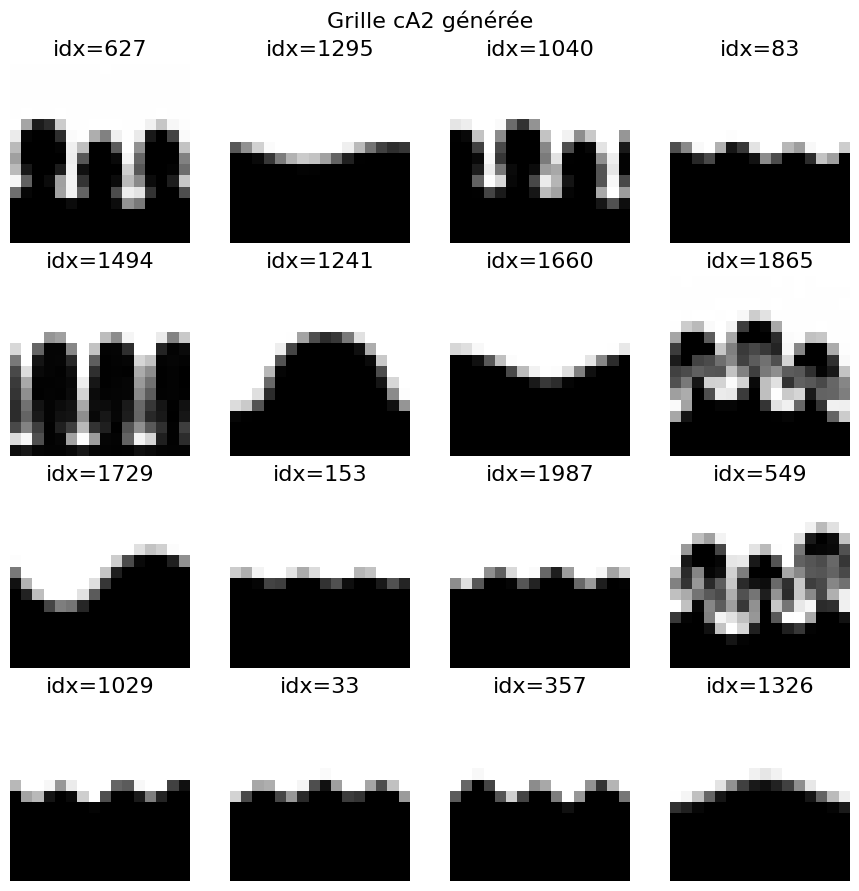

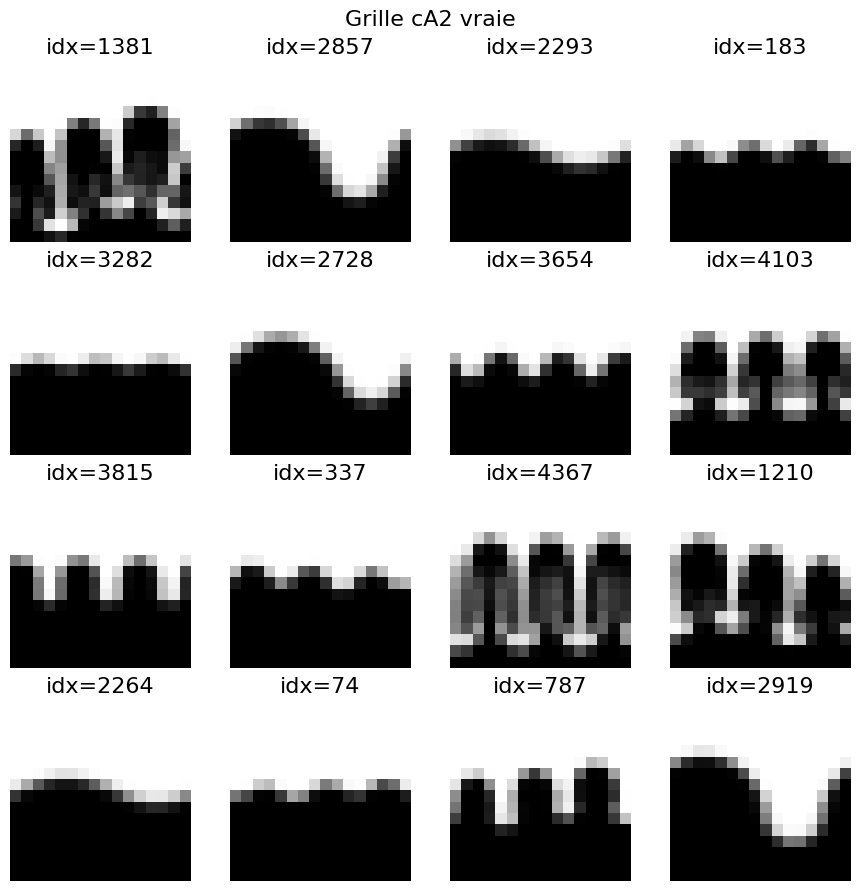

In [9]:
show_grid(generated_coeffs[COARSE_KEY], n=16, cols=4, seed=SEED,cmap=CMAP, title=f"Grille cA{COARSE_LEVEL} générée")
show_grid(real_coeffs[COARSE_LEVEL][:, 0:1], n=16, cols=4, seed=SEED, cmap=CMAP, title=f"Grille cA{COARSE_LEVEL} vraie")


In [10]:
print_phyfid_stage_result(f"coarse cA{COARSE_LEVEL}")


PhyFID coarse cA2 | n=1000 | encoder=coarse_cA2_phyfid_encoder.pt | ref vs ref=0.0000 | ref vs generated=0.0001


---
## Comparaison des coefficients générés à chaque niveau

/tmp/ipykernel_20832/1407919444.py:3: RuntimeWarning: invalid value encountered in log
  np.log(real_coeffs[level] + 1e-8),
/tmp/ipykernel_20832/1407919444.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log(real_coeffs[level] + 1e-8),
/tmp/ipykernel_20832/1407919444.py:4: RuntimeWarning: invalid value encountered in log
  np.log(generated_coeffs[level] + 1e-8),
/tmp/ipykernel_20832/1407919444.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log(generated_coeffs[level] + 1e-8),


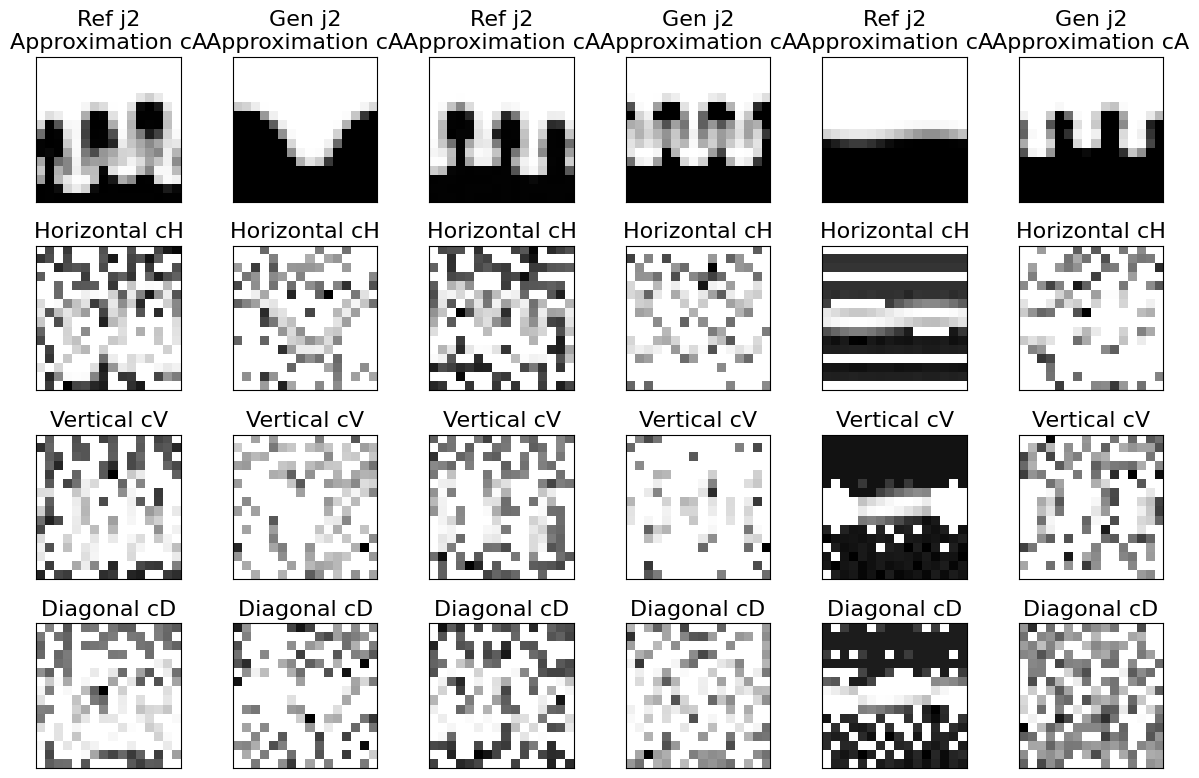

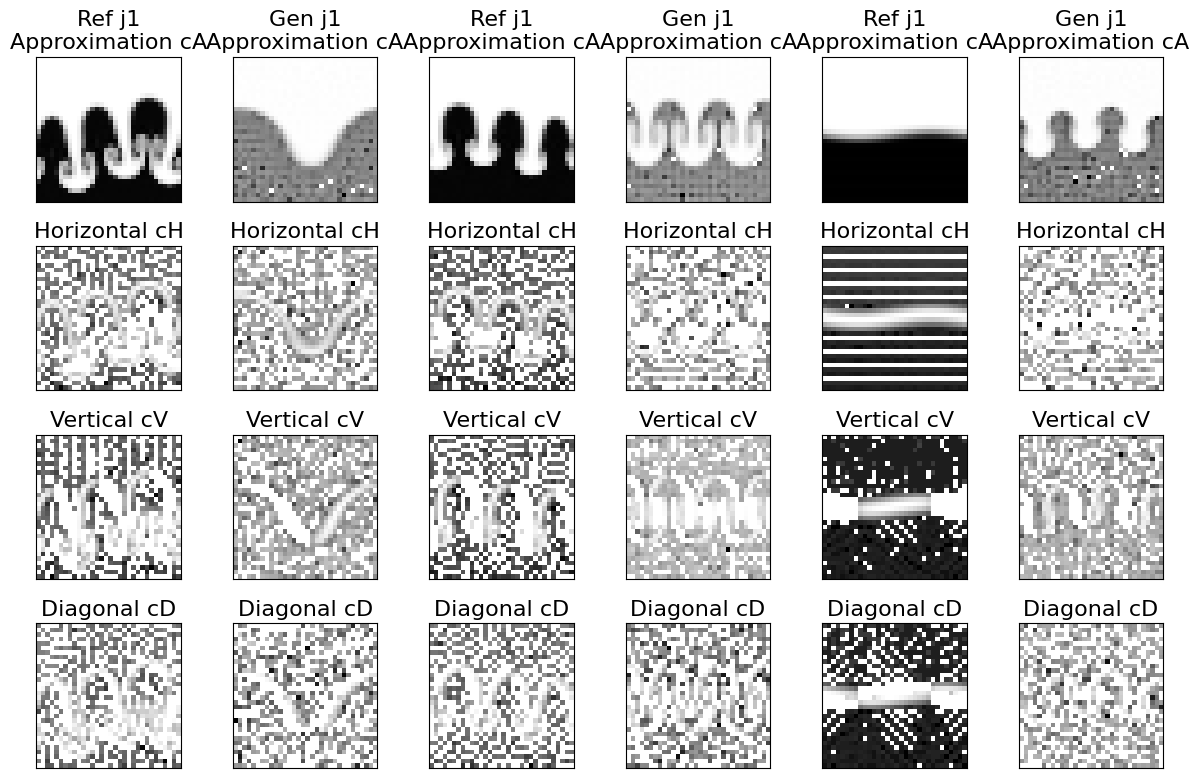

In [11]:
for level in CASCADE_LEVELS:
    plot_wavelet_level_comparison(
        np.log(real_coeffs[level] + 1e-8),
        np.log(generated_coeffs[level] + 1e-8),
        level=level,
        n_examples=3,
        seed=SEED,
        cmap=CMAP,
    )


---
## Comparaison des approximations intermédiaires reconstruites

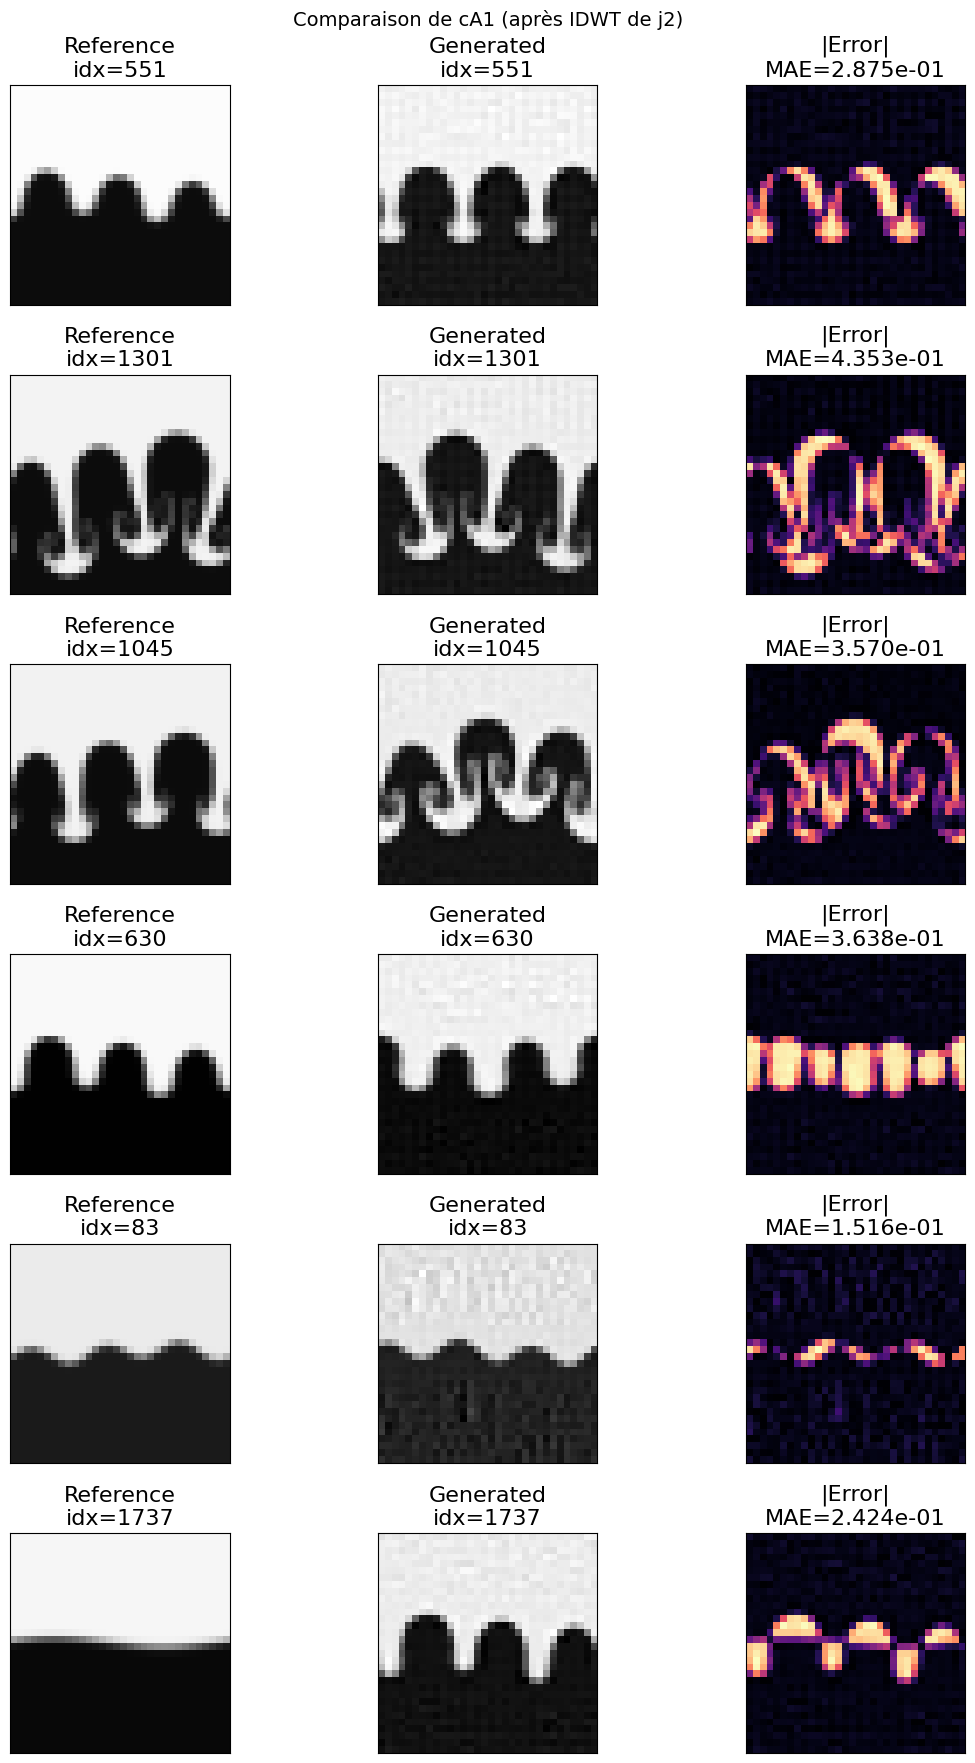

PhyFID w2 -> cA1 projete 64 | n=1000 | encoder=64phyfid_encoder.pt | ref vs ref=0.5001 | ref vs generated=2.8304


In [12]:
for level in sorted(reconstructed_ca, reverse=True):
    plot_single_channel_comparison(
        real_coeffs[level][:, 0:1],
        reconstructed_ca[level],
        title=f"Comparaison de cA{level} (après IDWT de j{level + 1})",
        n_examples=6,
        seed=SEED,
        cmap=CMAP
    )
print_phyfid_stage_result("w2 -> cA1 projete 64")


---
## Comparaison des images finales reconstruites

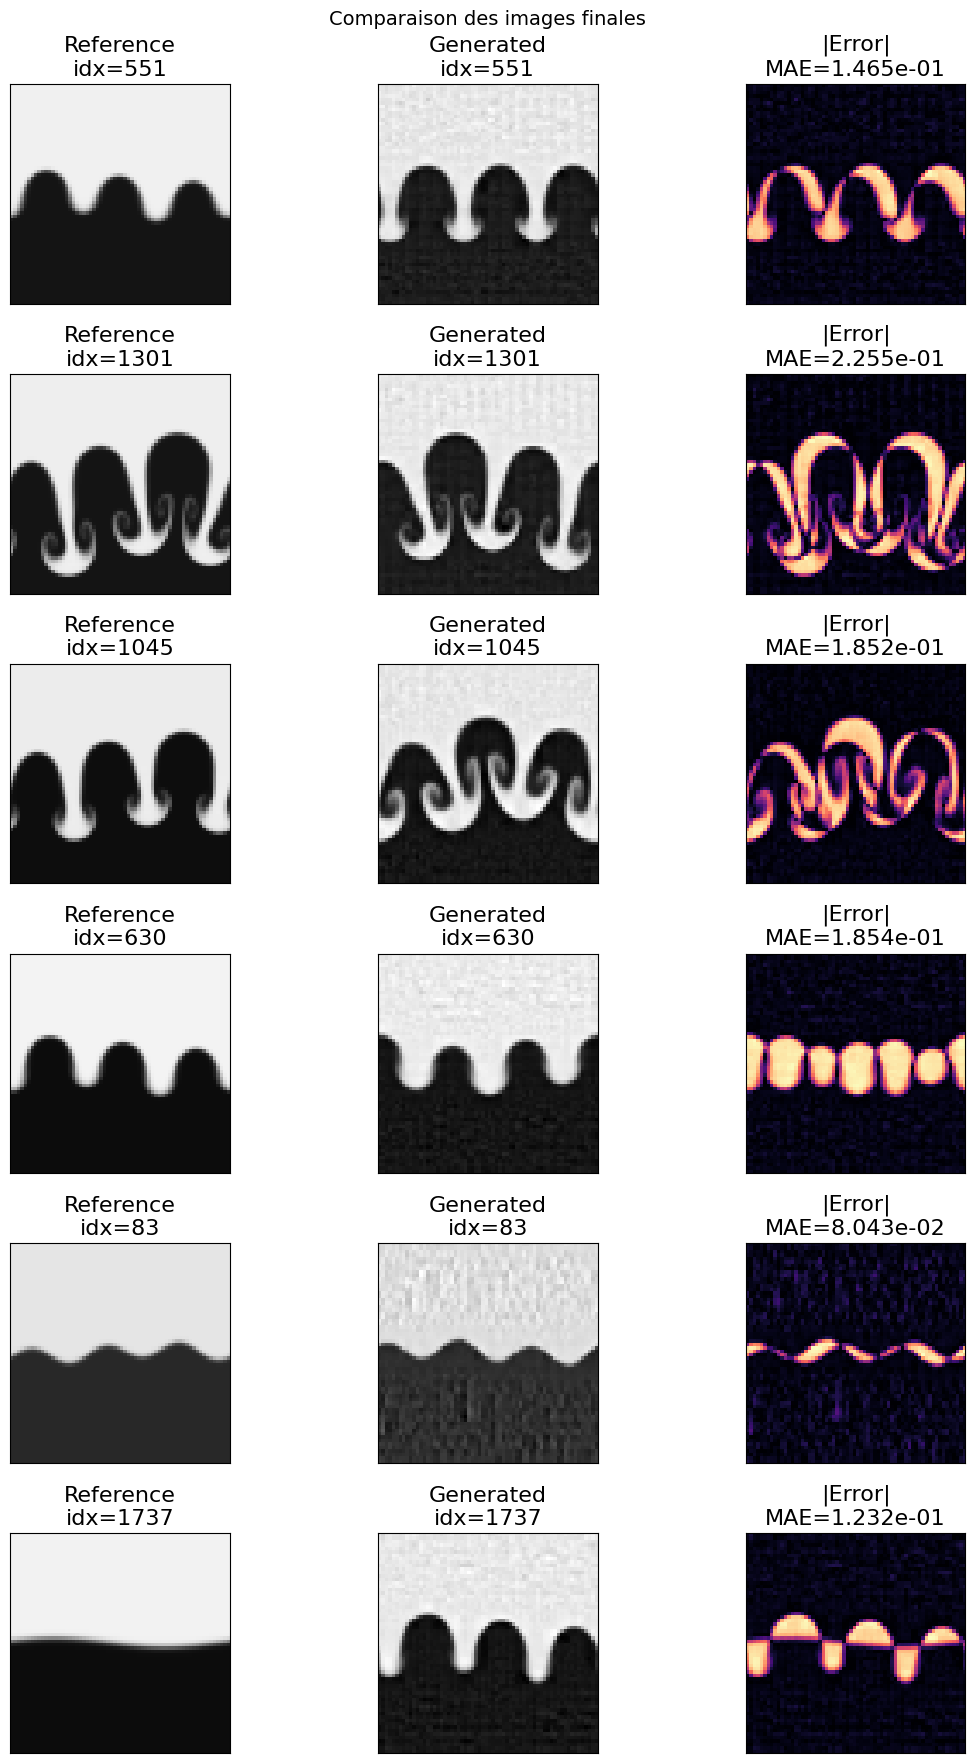

PhyFID w1 -> image finale | n=1000 | encoder=64phyfid_encoder.pt | ref vs ref=0.6658 | ref vs generated=3.0953


In [13]:
plot_single_channel_comparison(
    final_real_images,
    final_generated_images,
    title="Comparaison des images finales",
    n_examples=6,
    seed=SEED,
    cmap=CMAP
)
print_phyfid_stage_result("w1 -> image finale")


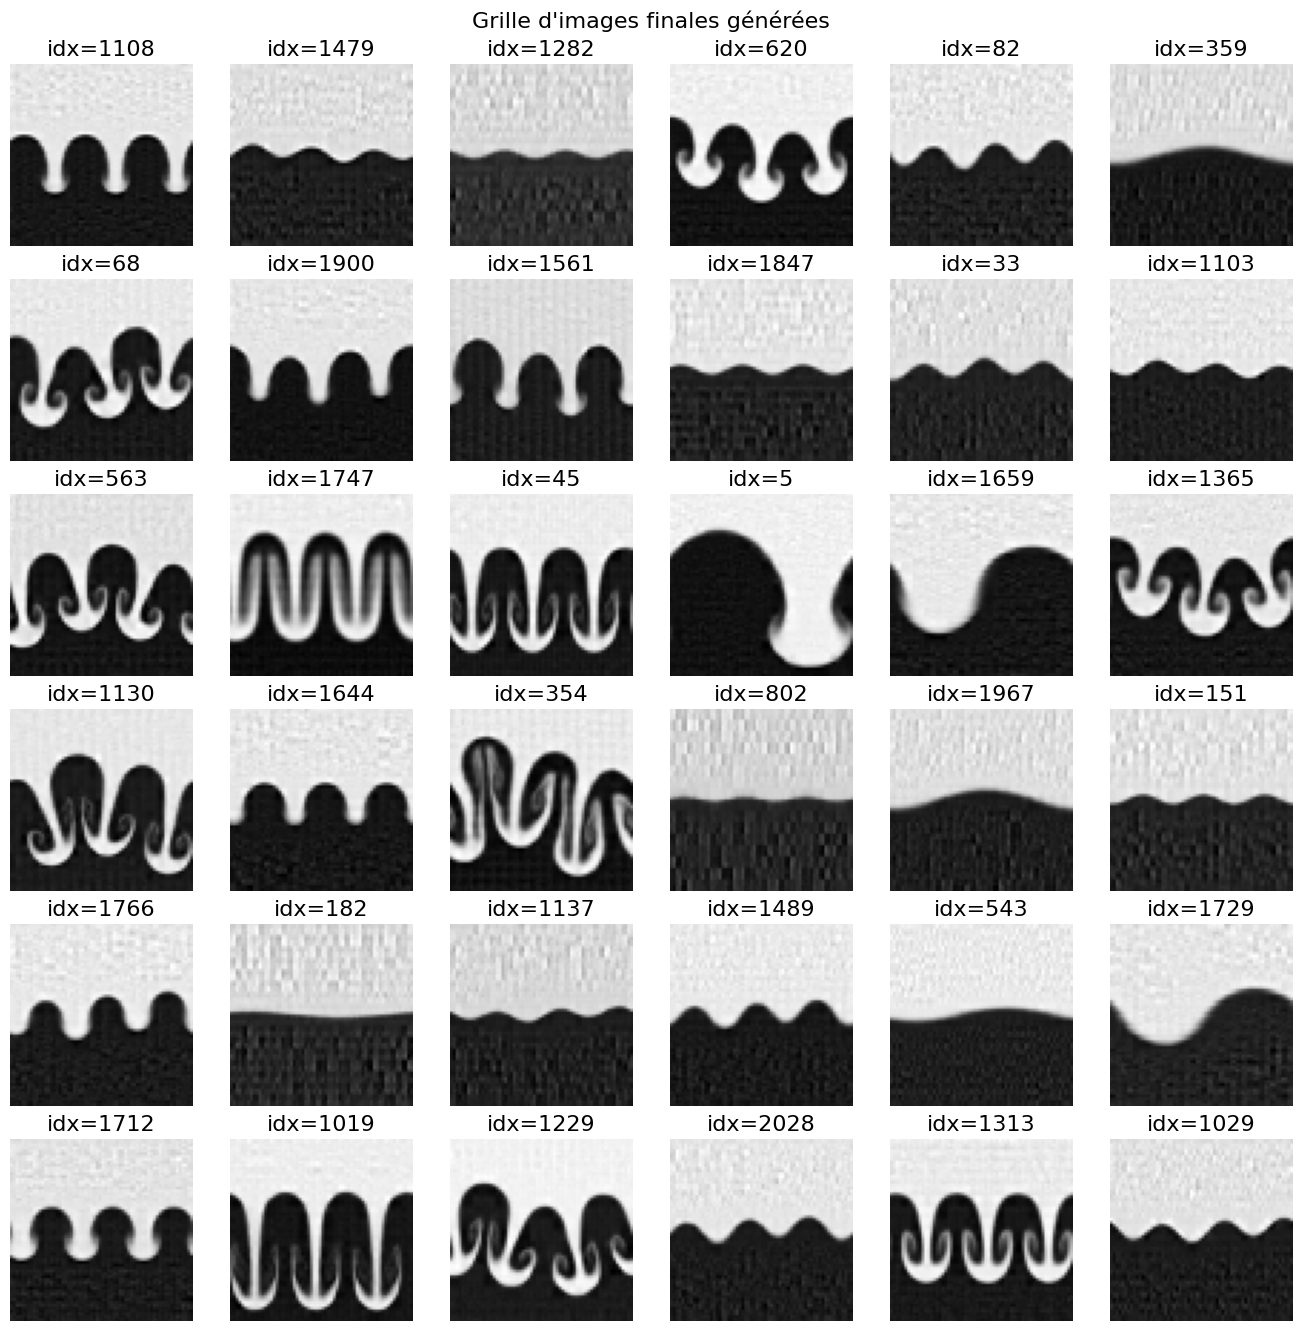

In [14]:
# show_grid(final_real_images, n=N_SAMPLES, cols=4, seed=SEED, title="Grille d'images finales de référence")
show_grid(final_generated_images, n=36, cols=6, cmap=CMAP, seed=SEED, title="Grille d'images finales générées")


---
## Figures rapport : cascade wavelet finale

Cette section reconstruit les deux figures utilisées dans le chapitre 5 du rapport. Elle est volontairement autonome : elle recharge directement les coefficients `j1` réels, les coefficients `j1` générés par la cascade et les images finales générées.


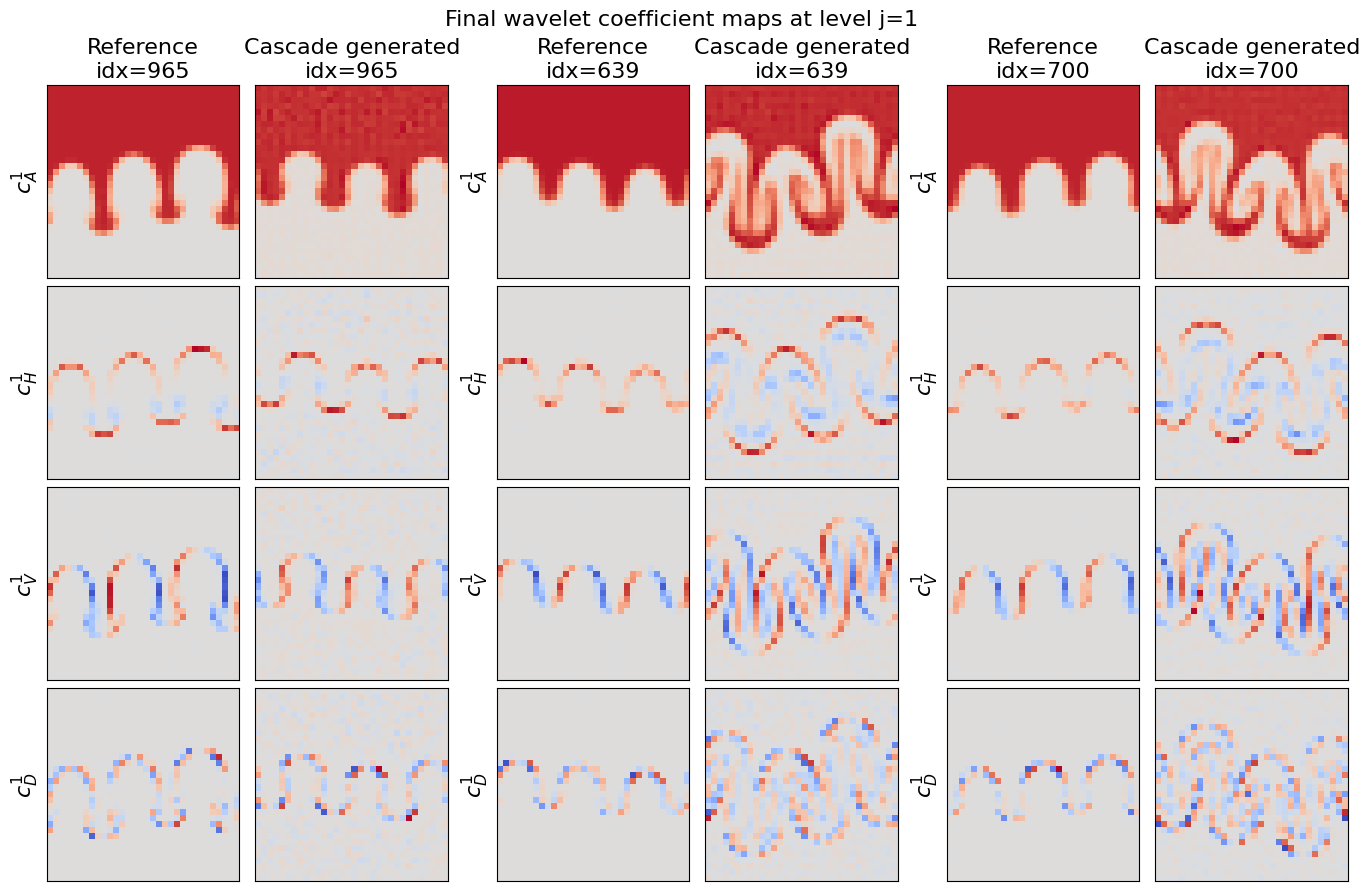

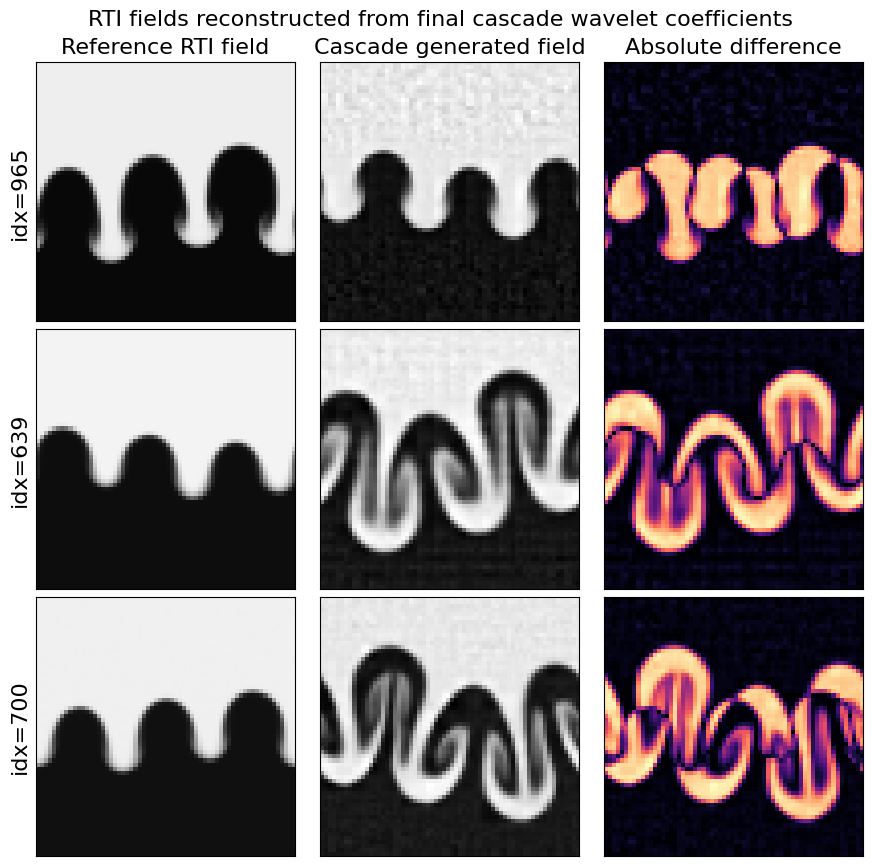

Saved:
/home/chapuissamuel/Documents/code/RT-Diffusion/doc/BDRPReportTemplate/figures/ch5/wavelet_cascade_coefficients_comparison.png
/home/chapuissamuel/Documents/code/RT-Diffusion/doc/BDRPReportTemplate/figures/ch5/wavelet_cascade_reconstruction_comparison.png


In [15]:
REPORT_FIGURE_DIR = project_root / "doc" / "BDRPReportTemplate" / "figures" / "ch5"
REPORT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

REPORT_REAL_J1 = DATA_ROOT / f"j1_{DATASET}.pt"
REPORT_GENERATED_J1 = OUTPUT_DIR / "j1_generated_coefficients.pt"
REPORT_GENERATED_IMAGES = OUTPUT_DIR / "generated_images.pt"

report_real_coeffs = load_pt_dataset(REPORT_REAL_J1).float()
report_generated_coeffs = load_pt_dataset(REPORT_GENERATED_J1).float()
report_generated_images = load_pt_dataset(REPORT_GENERATED_IMAGES).float()

# Fixed indices reproduce the figures inserted in the report.
REPORT_INDICES = [965, 639, 700]
REPORT_INDICES = [
    index for index in REPORT_INDICES
    if index < min(len(report_real_coeffs), len(report_generated_coeffs), len(report_generated_images))
]

if not REPORT_INDICES:
    raise ValueError("Aucun indice valide pour construire les figures du rapport.")

channel_names = [r"$c_A^1$", r"$c_H^1$", r"$c_V^1$", r"$c_D^1$"]

fig, axes = plt.subplots(4, 2 * len(REPORT_INDICES), figsize=(4.5 * len(REPORT_INDICES), 8.8), constrained_layout=True)
if len(REPORT_INDICES) == 1:
    axes = axes.reshape(4, 2)

for example, index in enumerate(REPORT_INDICES):
    c0 = 2 * example
    for channel in range(4):
        reference = report_real_coeffs[index, channel].detach().cpu().numpy()
        generated = report_generated_coeffs[index, channel].detach().cpu().numpy()
        vmax = max(abs(reference).max(), abs(generated).max())
        vmin = -vmax

        axes[channel, c0].imshow(reference, cmap="coolwarm", vmin=vmin, vmax=vmax)
        axes[channel, c0 + 1].imshow(generated, cmap="coolwarm", vmin=vmin, vmax=vmax)
        axes[channel, c0].set_ylabel(channel_names[channel], fontsize=16)

        for axis in (axes[channel, c0], axes[channel, c0 + 1]):
            axis.set_xticks([])
            axis.set_yticks([])

        if channel == 0:
            axes[channel, c0].set_title(f"Reference\nidx={index}", fontsize=16)
            axes[channel, c0 + 1].set_title(f"Cascade generated\nidx={index}", fontsize=16)

fig.suptitle("Final wavelet coefficient maps at level j=1", fontsize=16)
coefficients_figure_path = REPORT_FIGURE_DIR / "wavelet_cascade_coefficients_comparison.png"
fig.savefig(coefficients_figure_path, bbox_inches="tight", dpi=300)
plt.show()


def reconstruct_report_sample(coefficients):
    coefficients = coefficients.detach().cpu().numpy()
    return pywt.idwt2(
        (coefficients[0], (coefficients[1], coefficients[2], coefficients[3])),
        wavelet=WAVELET,
        mode=BORDER_MODE,
    )

report_reference_images = np.stack(
    [reconstruct_report_sample(report_real_coeffs[index]) for index in REPORT_INDICES],
    axis=0,
)
report_generated_images_np = squeeze_channel(report_generated_images).detach().cpu().numpy()

fig, axes = plt.subplots(len(REPORT_INDICES), 3, figsize=(8.7, 2.85 * len(REPORT_INDICES)), constrained_layout=True)
if len(REPORT_INDICES) == 1:
    axes = axes[None, :]

for row, index in enumerate(REPORT_INDICES):
    reference = report_reference_images[row]
    generated = report_generated_images_np[index]
    error = np.abs(reference - generated)
    vmin = min(reference.min(), generated.min())
    vmax = max(reference.max(), generated.max())

    axes[row, 0].imshow(reference, cmap="gray", vmin=vmin, vmax=vmax)
    axes[row, 1].imshow(generated, cmap="gray", vmin=vmin, vmax=vmax)
    axes[row, 2].imshow(error, cmap="magma")
    axes[row, 0].set_ylabel(f"idx={index}", fontsize=16)

    for axis in axes[row]:
        axis.set_xticks([])
        axis.set_yticks([])

axes[0, 0].set_title("Reference RTI field", fontsize=16)
axes[0, 1].set_title("Cascade generated field", fontsize=16)
axes[0, 2].set_title("Absolute difference", fontsize=16)
fig.suptitle("RTI fields reconstructed from final cascade wavelet coefficients", fontsize=16)
reconstruction_figure_path = REPORT_FIGURE_DIR / "wavelet_cascade_reconstruction_comparison.png"
fig.savefig(reconstruction_figure_path, bbox_inches="tight", dpi=300)
plt.show()

print("Saved:")
print(coefficients_figure_path)
print(reconstruction_figure_path)



---
## Cascade complète : accumulation d'erreur

Cette section utilise `cascade_sgm_hcirc_blurpool_eps00001`, où le coarse cA2 est lui-même échantillonné par le SGM. La comparaison avec l'ablation oracle quantifie l'effet de la propagation de cette erreur dans les niveaux j2 puis j1. Les scores ne doivent donc pas être interprétés comme un résultat final exploitable sans correction de cette accumulation.

Erreur coarse cA2 : MAE=0.67446, RMSE=1.23170
WSGM cascade complète — coarse généré: n=1000 | PhyFID(ref/ref)=0.66575 | PhyFID(ref/gen)=3.09526 | spectral L1=0.32394 | log-spectrum RMSE=0.65716 | energy ratio=0.20861


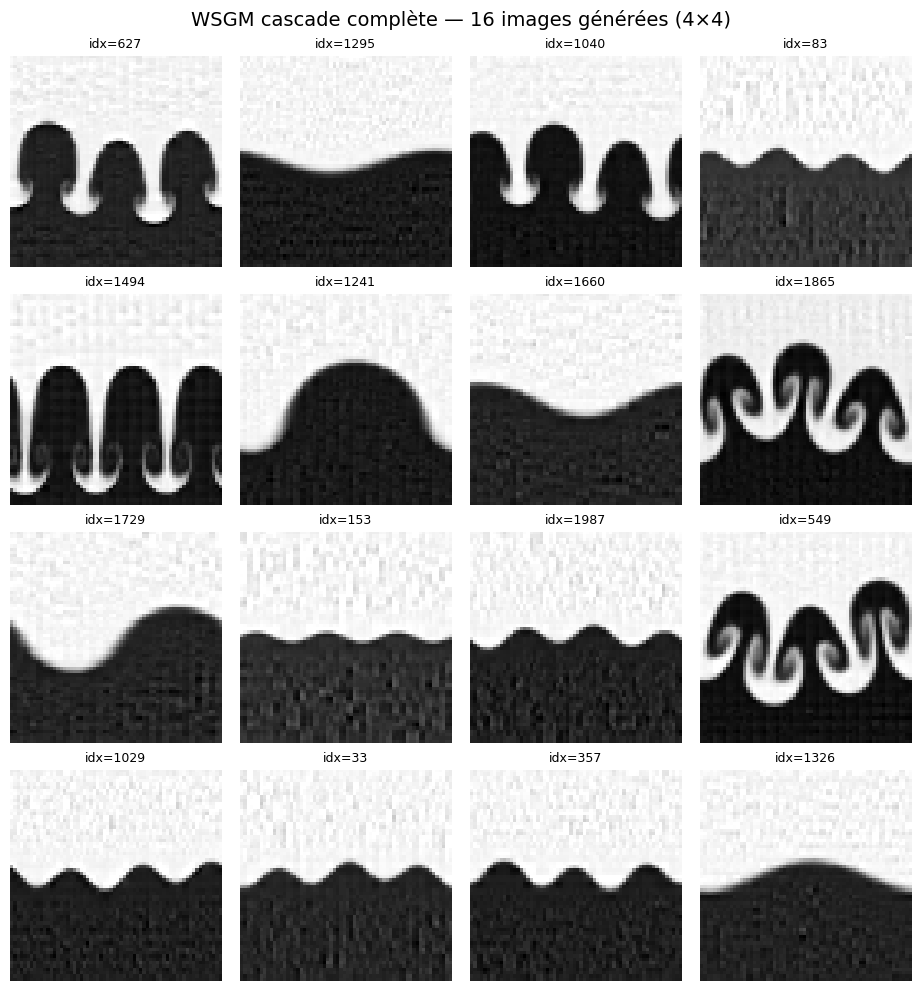

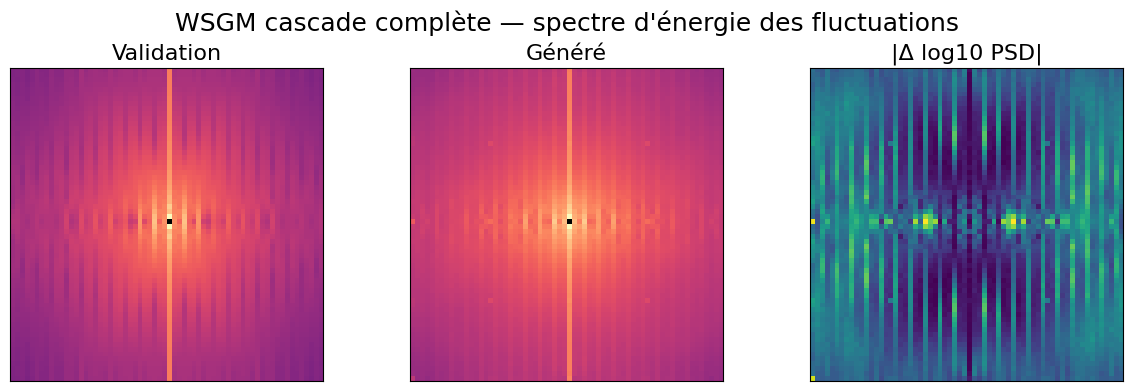

(<Figure size 1200x380 with 3 Axes>,
 {'spectral_l1': 0.32394455541823153,
  'log_spectral_rmse': 0.6571560980433614,
  'total_energy_ratio': 0.20861048083350586,
  'reference_energy': array([[0.0649262 , 0.07510536, 0.09789815, ..., 0.06306563, 0.09789815,
          0.07510536],
         [0.07565231, 0.07899614, 0.10703672, ..., 0.06491452, 0.10703672,
          0.07899614],
         [0.07660476, 0.07888215, 0.10916239, ..., 0.06812708, 0.10916239,
          0.07888215],
         ...,
         [0.07909286, 0.07760859, 0.10755375, ..., 0.07415997, 0.10755375,
          0.07760859],
         [0.07660476, 0.07888215, 0.10916239, ..., 0.06812708, 0.10916239,
          0.07888215],
         [0.07565231, 0.07899614, 0.10703672, ..., 0.06491452, 0.10703672,
          0.07899614]], shape=(64, 64)),
  'generated_energy': array([[0.71465954, 0.05583277, 0.07030256, ..., 0.04980575, 0.07030256,
          0.05583277],
         [0.07482873, 0.05743609, 0.07937631, ..., 0.07085152, 0.07395763,
    

In [16]:
from result_utils import (
    compare_result_metrics,
    plot_image_grid,
    plot_spectral_energy,
    print_result_metrics,
)

cascade_metrics = compare_result_metrics(
    final_real_images,
    final_generated_images,
    PHYFID_ENCODER_64,
    max_images=PHYFID_MAX_IMAGES,
    batch_size=PHYFID_BATCH_SIZE,
)
coarse_reference = real_coeffs[COARSE_LEVEL][:, :1]
coarse_error = (
    generated_coeffs[COARSE_KEY][:len(coarse_reference)] - coarse_reference[:len(generated_coeffs[COARSE_KEY])]
).abs()
print(f"Erreur coarse cA{COARSE_LEVEL} : MAE={coarse_error.mean():.5f}, RMSE={coarse_error.square().mean().sqrt():.5f}")
print_result_metrics("WSGM cascade complète — coarse généré", cascade_metrics)
plot_image_grid(
    final_generated_images, n=16, cols=4, seed=SEED, cmap=CMAP,
    title="WSGM cascade complète — 16 images générées (4×4)",
)
plot_spectral_energy(
    final_real_images[:cascade_metrics["n"]],
    final_generated_images[:cascade_metrics["n"]],
    title="WSGM cascade complète — spectre d'énergie des fluctuations",
)

In [17]:
from scipy.stats import skewnorm


def to_txy(tensor):
    """Converts an image tensor to canonical shape ``(t, x, y)``.

    Args:
        tensor (torch.Tensor | np.ndarray): Input data with shape ``(t, x, y)``
            or ``(t, 1, x, y)``.

    Returns:
        torch.Tensor: Floating-point tensor with shape ``(t, x, y)``.

    Raises:
        ValueError: If the data cannot be interpreted as a time-indexed 2D field.
    """
    tensor = torch.as_tensor(tensor).float()
    if tensor.ndim == 4 and tensor.shape[1] == 1:
        tensor = tensor[:, 0]
    if tensor.ndim != 3:
        raise ValueError(f"Expected tensor in (t, x, y) or (t, 1, x, y), got {tuple(tensor.shape)}")
    return tensor


def normalize_01(tensor, normalize=True):
    """Normalizes fields in the ``[0, 1]`` convention.

    Args:
        tensor (torch.Tensor | np.ndarray): Data with shape ``(t, x, y)`` or
            ``(t, 1, x, y)``.
        normalize (bool, optional): If ``True``, divides by 255 when the values
            appear to be in the ``[0, 255]`` convention. Defaults to True.

    Returns:
        torch.Tensor: Floating-point data with shape ``(t, x, y)``.
    """
    tensor = to_txy(tensor)
    if normalize and tensor.max() > 1.5:
        tensor = tensor / 255.0
    return tensor


def fit_skewnorm_1d(values, min_scale=1e-6, max_abs_alpha=50):
    """Fits a skew-normal distribution to a 1D vector.

    Args:
        values (array-like): 1D samples to fit.
        min_scale (float, optional): Minimum allowed width to avoid a
            numerically singular density. Defaults to 1e-6.
        max_abs_alpha (float, optional): Maximum absolute value of the returned
            skewness parameter. Defaults to 50.

    Returns:
        tuple[float, float, float]: ``(alpha, loc, scale)`` parameters of
            ``scipy.stats.skewnorm``.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 0.0, 0.0, min_scale

    mean = float(np.mean(values))
    std = float(np.std(values))
    if values.size < 3 or std < min_scale:
        return 0.0, mean, max(std, min_scale)

    try:
        alpha, loc, scale = skewnorm.fit(values)
        if not np.isfinite([alpha, loc, scale]).all() or scale < min_scale:
            raise ValueError("Invalid skew-normal parameters")
        alpha = float(np.clip(alpha, -max_abs_alpha, max_abs_alpha))
        return alpha, float(loc), float(scale)
    except Exception:
        return 0.0, mean, max(std, min_scale)


def fit_skewnorm_layers(layer_values):
    """Fits a skew-normal distribution for each spatial row.

    Args:
        layer_values (array-like): Array with shape ``(t, x)`` containing a row
            statistic for each time and each row.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: ``alpha``, ``loc``, and
            ``scale`` arrays with shape ``(x,)``.
    """
    layer_values = np.asarray(layer_values, dtype=float)
    params = np.array([fit_skewnorm_1d(layer_values[:, i]) for i in range(layer_values.shape[1])])
    return params[:, 0], params[:, 1], params[:, 2]


def as_txy_numpy(data):
    """Converts image fields to an ``ndarray`` with shape ``(t, x, y)``.

    Args:
        data (torch.Tensor | np.ndarray): Data with shape ``(t, x, y)`` or
            ``(t, 1, x, y)``.

    Returns:
        np.ndarray: Floating-point data with shape ``(t, x, y)``.

    Raises:
        ValueError: If the data shape is not supported.
    """
    if torch.is_tensor(data):
        data = data.detach().cpu().numpy()
    data = np.asarray(data, dtype=float)
    if data.ndim == 4 and data.shape[1] == 1:
        data = data[:, 0]
    if data.ndim != 3:
        raise ValueError(f"Expected data in (t, x, y) or (t, 1, x, y), got {data.shape}")
    return data


def line_metric(validation, generated, metric_name="mu"):
    """Compares two field datasets using row profiles.

    Args:
        validation (torch.Tensor | np.ndarray): Reference dataset with shape
            ``(t, x, y)`` or ``(t, 1, x, y)``.
        generated (torch.Tensor | np.ndarray): Compared dataset with shape
            ``(t, x, y)`` or ``(t, 1, x, y)``.
        metric_name (str, optional): Compared profile type. ``"mu"`` compares
            the temporal mean of ``mean_y``; ``"sigma"`` compares its temporal
            standard deviation. Defaults to "mu".

    Returns:
        tuple[float, np.ndarray, np.ndarray]: Normalized distance, profile of
            the compared dataset, and profile of the validation dataset.

    Raises:
        ValueError: If the two datasets do not have the same number of rows or
            if ``metric_name`` is not supported.
    """
    validation = as_txy_numpy(validation)
    generated = as_txy_numpy(generated)
    if validation.shape[1] != generated.shape[1]:
        raise ValueError(f"The number of x rows must be the same for validation and generated: {validation.shape[1]} vs {generated.shape[1]}")

    n_x = validation.shape[1]
    mu_val = validation.mean(axis=2)
    mu_gen = generated.mean(axis=2)
    if metric_name == "mu":
        MU_l_val = np.mean(mu_val, axis=0)
        MU_l_gen = np.mean(mu_gen, axis=0)
        distance = np.linalg.norm(MU_l_val - MU_l_gen) / n_x
        return distance, MU_l_gen, MU_l_val 
    elif metric_name == "sigma":
        SIGMA_l_val = np.std(mu_val, axis=0)
        SIGMA_l_gen = np.std(mu_gen, axis=0)
        distance = np.linalg.norm(SIGMA_l_val - SIGMA_l_gen) / n_x
        return distance, SIGMA_l_gen, SIGMA_l_val
    else:
        raise ValueError(f"Unsupported metric: {metric_name}")
    

def get_alpha(data):
    """Fits a skew-normal distribution to the row means of a dataset.

    Args:
        data (torch.Tensor | np.ndarray): Data with shape ``(t, x, y)`` or
            ``(t, 1, x, y)``.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: ``alpha``, ``loc``, and
            ``scale`` arrays with shape ``(x,)``.
    """
    data = as_txy_numpy(data)
    d = data.mean(axis=2)
    ALPHA_l_val, LOC_l_val, SCALE_l_val = fit_skewnorm_layers(d)
    return ALPHA_l_val, LOC_l_val, SCALE_l_val


def skewnorm_pdf(x, alpha, loc, scale):
    """Evaluates the density of a skew-normal distribution.

    Args:
        x (np.ndarray): Points at which to evaluate the density.
        alpha (float): Skewness parameter.
        loc (float): Location parameter.
        scale (float): Scale parameter.

    Returns:
        np.ndarray: Density values at points ``x``.
    """
    scale = float(scale)
    if scale <= 0:
        return np.zeros_like(x)
    return skewnorm.pdf(x, float(alpha), loc=float(loc), scale=scale)


def plot_skewnorm_joyplot(n_curves, alpha1, loc1, scale1, alpha2=None, loc2=None, scale2=None, *, ax=None, title="", label1="Validation", label2="Generated", color1="tab:blue", color2="tab:orange", x_min=-0.05, x_max=1.05):
    """Plots a row-wise joyplot of skew-normal distributions.

    Args:
        n_curves (int): Number of rows to display between the top and bottom
            boundaries of the field.
        alpha1 (array-like): Skewness parameters of the first dataset, shape ``(x,)``.
        loc1 (array-like): Location parameters of the first dataset, shape ``(x,)``.
        scale1 (array-like): Scale parameters of the first dataset, shape ``(x,)``.
        alpha2 (array-like, optional): Skewness parameters of the second dataset.
            Defaults to None.
        loc2 (array-like, optional): Location parameters of the second dataset.
            Defaults to None.
        scale2 (array-like, optional): Scale parameters of the second dataset.
            Defaults to None.
        ax (matplotlib.axes.Axes, optional): Axes on which to plot. Defaults to None.
        title (str, optional): Subplot title. Defaults to "".
        label1 (str, optional): Label of the first dataset. Defaults to "Validation".
        label2 (str, optional): Label of the second dataset. Defaults to "Generated".
        color1 (str, optional): Color of the first dataset. Defaults to "tab:blue".
        color2 (str, optional): Color of the second dataset. Defaults to "tab:orange".
        x_min (float, optional): Lower bound of the horizontal axis. Defaults to -0.05.
        x_max (float, optional): Upper bound of the horizontal axis. Defaults to 1.05.

    Returns:
        matplotlib.axes.Axes: Axes containing the joyplot.

    Raises:
        ValueError: If the parameter arrays have incompatible shapes.
    """
    alpha1 = np.asarray(alpha1)
    loc1 = np.asarray(loc1)
    scale1 = np.asarray(scale1)
    if alpha1.shape != loc1.shape or loc1.shape != scale1.shape:
        raise ValueError("alpha1, loc1, and scale1 must have the same shape")

    has_second = alpha2 is not None and loc2 is not None and scale2 is not None
    if has_second:
        alpha2 = np.asarray(alpha2)
        loc2 = np.asarray(loc2)
        scale2 = np.asarray(scale2)
        if alpha2.shape != loc2.shape or loc2.shape != scale2.shape or loc2.shape != loc1.shape:
            raise ValueError("alpha2/loc2/scale2 must have the same shape as alpha1/loc1/scale1")

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 3.5))

    n_curves = min(int(n_curves), len(loc1))
    selected_idx = np.linspace(0, len(loc1) - 1, n_curves, dtype=int)
    x = np.linspace(x_min, x_max, 800)
    spacing = 1.0
    height = 0.55

    for plot_idx, layer_idx in enumerate(selected_idx):
        offset = plot_idx * spacing

        y1 = skewnorm_pdf(x, alpha1[layer_idx], loc1[layer_idx], scale1[layer_idx])
        y1 = y1 / y1.max() * height if y1.max() > 0 else y1
        ax.fill_between(x, offset, offset + y1, color=color1, alpha=0.35)
        ax.plot(x, offset + y1, color=color1, linewidth=1.2, label=label1 if plot_idx == 0 else None)
        ax.axvline(loc1[layer_idx], ymin=offset / (n_curves * spacing), ymax=(offset + height) / (n_curves * spacing), color=color1, linestyle="--", linewidth=0.8, alpha=0.7)

        if has_second:
            y2 = skewnorm_pdf(x, alpha2[layer_idx], loc2[layer_idx], scale2[layer_idx])
            y2 = y2 / y2.max() * height if y2.max() > 0 else y2
            ax.fill_between(x, offset, offset + y2, color=color2, alpha=0.30)
            ax.plot(x, offset + y2, color=color2, linewidth=1.2, label=label2 if plot_idx == 0 else None)
            ax.axvline(loc2[layer_idx], ymin=offset / (n_curves * spacing), ymax=(offset + height) / (n_curves * spacing), color=color2, linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_xlim(x_min, x_max)
    ax.set_yticks(np.arange(n_curves) * spacing)
    ax.set_yticklabels([f"x={i}" for i in selected_idx])
    ax.set_xlabel(r"$\mu_l$")
    ax.set_ylabel("Row index")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    if has_second:
        ax.legend(loc="upper right")
    return ax


In [18]:
DATA_ROOT = "../data/RT64"
PROCESSED_ROOT = os.path.join(DATA_ROOT, "processed")
VAL_PT = os.path.join(PROCESSED_ROOT, "validation.pt")
val_images = load_pt_dataset(VAL_PT)
val_stats = normalize_01(val_images)
generated_stats = normalize_01(final_generated_images)



mu_l_dist_gen, mu_l_gen, mu_l_val = line_metric(val_stats, generated_stats, metric_name="mu")
sigma_l_dist_gen, sigma_l_gen, sigma_l_val = line_metric(val_stats, generated_stats, metric_name="sigma")
alpha_l_val, loc_l_val, scale_l_val = get_alpha(val_stats)
alpha_l_generated, loc_l_generated, scale_l_generated = get_alpha(generated_stats)

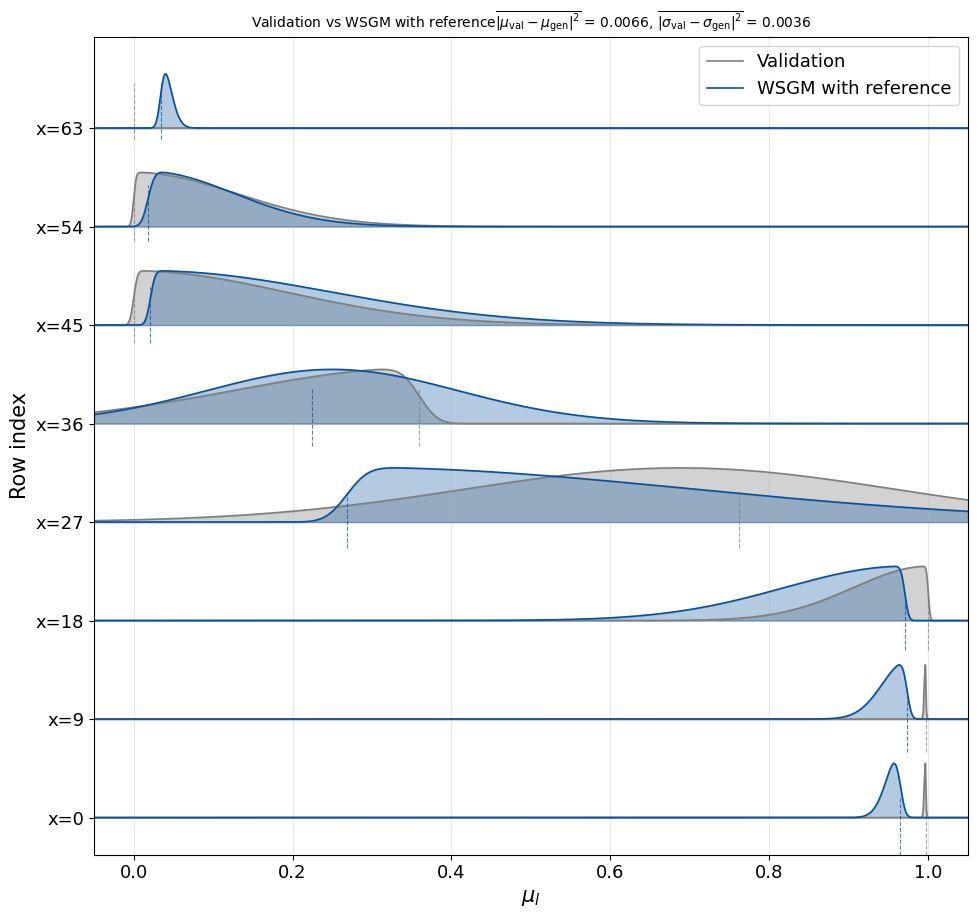

In [23]:
title_2 = (
    "Validation vs WSGM with reference"
    r"$\overline{|\mu_{\mathrm{val}} - \mu_{\mathrm{gen}}|^2}$"
    f" = {mu_l_dist_gen:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{gen}}|^2}$"
    f" = {sigma_l_dist_gen:.4f}"
)

n_curves = 8
subplot_title_fontsize = 10
fig, ax = plt.subplots(1, 1, figsize=(10, 10), sharex=True, sharey=True)
color1 = "gray"

plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_generated, loc_l_generated, scale_l_generated, ax=ax, title=title_2, label2="WSGM with reference", color1=color1, color2="#08519c")
ax.title.set_fontsize(subplot_title_fontsize)

# fig.suptitle(r"Skew-normal distribution of row-averaged density $\overline{\rho_{i,x}}(y)$", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.0, w_pad=1.5)
plt.savefig("../doc/BDRPReportTemplate/figures/ch5/WSGM_gen_joyplot.png", bbox_inches="tight", dpi=300)
plt.show()